In [1]:
# ResNet CNN for ERA5 Wave Spectra with Physics Constraints (Direct Prediction)
import numpy as np
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import torch.nn.functional as F

print("Libraries imported successfully")

Libraries imported successfully


In [7]:
# Load processed data
data_path = "data\processed"
arrays = []

# Load all processed files
for file in os.listdir(data_path):
    print(f"Processing file: {file}")
    full_path = os.path.join(data_path, file)
    print(f"Loading {file}")
    data = np.load(full_path, allow_pickle=False)
    print(f"  Keys: {list(data.keys())}")
    print(f"  X shape: {data['X'].shape}")
    print(f"  y shape: {data['y'].shape}")
    arrays.append(data)

# Combine all samples
total_samples = sum(len(arr['X']) for arr in arrays)
print(f"Total samples: {total_samples}")

# Initialize arrays for combined data
combined_X = []
combined_y = []

for arr in arrays:
    combined_X.append(arr['X'])
    combined_y.append(arr['y'])

# Convert to numpy arrays and extract features
X_combined = np.concatenate(combined_X, axis=0)  # Shape: (samples, 5, 30)
y_combined = np.concatenate(combined_y, axis=0)  # Shape: (samples, 30, 24)

# Extract ALL components from X (use ALL 5 components: S1D, a1, b1, a2, b2)
S1D = X_combined[:, 0, :]  # 1D spectra: (samples, 30)
a1 = X_combined[:, 1, :]   # Directional moment a1: (samples, 30)  
b1 = X_combined[:, 2, :]   # Directional moment b1: (samples, 30)
a2 = X_combined[:, 3, :]   # Directional moment a2: (samples, 30) - INCLUDED
b2 = X_combined[:, 4, :]   # Directional moment b2: (samples, 30) - INCLUDED
S2D = y_combined           # 2D spectra: (samples, 30, 24)

print(f"Data shapes:")
print(f"S1D: {S1D.shape}")  
print(f"S2D: {S2D.shape}")
print(f"a1: {a1.shape}")
print(f"b1: {b1.shape}")
print(f"a2: {a2.shape}")   # NEW
print(f"b2: {b2.shape}")   # NEW

# Check for any NaN values in loaded data
print(f"NaN values in S1D: {np.isnan(S1D).sum()}")
print(f"NaN values in S2D: {np.isnan(S2D).sum()}")
print(f"NaN values in a1: {np.isnan(a1).sum()}")
print(f"NaN values in b1: {np.isnan(b1).sum()}")
print(f"NaN values in a2: {np.isnan(a2).sum()}")  # NEW
print(f"NaN values in b2: {np.isnan(b2).sum()}")  # NEW

<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2488\615587787.py:2: SyntaxWarning: invalid escape sequence '\p'
  data_path = "data\processed"


Processing file: era5_wave_training.npz
Loading era5_wave_training.npz
  Keys: ['X', 'y', 'freq_hz', 'direction_deg', 'valid_time']
  X shape: (9504, 5, 30)
  y shape: (9504, 30, 24)
Total samples: 9504
Data shapes:
S1D: (9504, 30)
S2D: (9504, 30, 24)
a1: (9504, 30)
b1: (9504, 30)
a2: (9504, 30)
b2: (9504, 30)
NaN values in S1D: 0
NaN values in S2D: 0
NaN values in a1: 0
NaN values in b1: 0
NaN values in a2: 0
NaN values in b2: 0


In [8]:
# Prepare inputs for ResNet CNN model (Direct Prediction)
print("Preparing inputs for ResNet CNN model (direct prediction)...")

# Create model inputs by stacking ALL features into channels
# Input: (batch, channels=5, freq=30) where channels = [S1D, a1, b1, a2, b2]
batch_size, n_freq, n_dir = S2D.shape

# Stack all features as channels for CNN input
inputs = np.stack([
    S1D,  # Channel 0: 1D spectrum
    a1,   # Channel 1: First harmonic moment a1
    b1,   # Channel 2: First harmonic moment b1
    a2,   # Channel 3: Second harmonic moment a2 - NEW
    b2    # Channel 4: Second harmonic moment b2 - NEW
], axis=1)  # Shape: (batch_size, 5, 30)

# Target is the full 2D spectrum (NOT residuals)
targets = S2D  # Shape: (batch_size, 30, 24)

print(f"Input shape: {inputs.shape} (batch, channels=5, freq=30)")
print(f"Target shape: {targets.shape} (batch, freq=30, dir=24)")
print(f"Input channels: S1D, a1, b1, a2, b2")
print(f"Mode: Direct 2D spectrum prediction (NOT residuals)")

# Check for any NaN values
nan_inputs = np.isnan(inputs).sum()
nan_targets = np.isnan(targets).sum()
print(f"NaN in inputs: {nan_inputs}")
print(f"NaN in targets: {nan_targets}")

if nan_inputs > 0 or nan_targets > 0:
    print("WARNING: NaN values detected! Will clean...")
    # Find rows with any NaN
    input_mask = ~np.isnan(inputs).any(axis=(1,2))
    target_mask = ~np.isnan(targets).any(axis=(1,2))
    valid_mask = input_mask & target_mask
    
    print(f"Valid samples: {valid_mask.sum()}/{len(valid_mask)}")
    
    # Filter out NaN samples
    inputs = inputs[valid_mask]
    targets = targets[valid_mask]
    S1D = S1D[valid_mask]
    a1 = a1[valid_mask] 
    b1 = b1[valid_mask]
    a2 = a2[valid_mask]
    b2 = b2[valid_mask]
    print(f"Cleaned input shape: {inputs.shape}")
    print(f"Cleaned target shape: {targets.shape}")

# Basic statistics
print(f"Input range: [{inputs.min():.6f}, {inputs.max():.6f}]")
print(f"Target range: [{targets.min():.6f}, {targets.max():.6f}]")
print(f"Input mean: {inputs.mean():.6f}, std: {inputs.std():.6f}")
print(f"Target mean: {targets.mean():.6f}, std: {targets.std():.6f}")

Preparing inputs for ResNet CNN model (direct prediction)...
Input shape: (9504, 5, 30) (batch, channels=5, freq=30)
Target shape: (9504, 30, 24) (batch, freq=30, dir=24)
Input channels: S1D, a1, b1, a2, b2
Mode: Direct 2D spectrum prediction (NOT residuals)
NaN in inputs: 0
NaN in targets: 0
Input range: [-0.991445, 22.504860]
Target range: [0.000000, 19.814178]
Input mean: -0.121308, std: 0.506509
Target mean: 0.025833, std: 0.173907


In [9]:
# Normalize inputs and split data
print("Normalizing inputs and splitting data...")

# Normalize inputs channel-wise for CNN
input_mean = inputs.mean(axis=(0, 2), keepdims=True)  # Mean over batch and frequency
input_std = inputs.std(axis=(0, 2), keepdims=True) + 1e-8  # Std over batch and frequency
inputs_norm = (inputs - input_mean) / input_std

# Save normalization parameters for later evaluation (proper deployment practice)
os.makedirs("models", exist_ok=True)
np.savez("models/resnet_phy_normalization.npz", input_mean=input_mean, input_std=input_std)
print(f"💾 Saved normalization parameters to models/resnet_phy_normalization.npz")

# Normalize targets by energy for better training stability
target_mean = targets.mean()
target_std = targets.std() + 1e-8
targets_norm = (targets - target_mean) / target_std

print(f"Input normalization per channel:")
for i, name in enumerate(['S1D', 'a1', 'b1', 'a2', 'b2']):
    print(f"  {name}: Mean={input_mean[0, i, 0]:.6f}, Std={input_std[0, i, 0]:.6f}")

print(f"Target normalization: Mean={target_mean:.6f}, Std={target_std:.6f}")
print(f"Normalized input range: [{inputs_norm.min():.6f}, {inputs_norm.max():.6f}]")
print(f"Normalized target range: [{targets_norm.min():.6f}, {targets_norm.max():.6f}]")

# Split data chronologically (proper for time-series wave data)
n_samples = len(inputs_norm)
n_train = int(0.7 * n_samples)
n_val = int(0.15 * n_samples)
n_test = n_samples - n_train - n_val

# Don't shuffle - preserve temporal structure
indices = np.arange(n_samples)  # Chronological order
train_idx = indices[:n_train]
val_idx = indices[n_train:n_train+n_val]
test_idx = indices[n_train+n_val:]

# Create splits
X_train, y_train = inputs_norm[train_idx], targets_norm[train_idx]
X_val, y_val = inputs_norm[val_idx], targets_norm[val_idx]
X_test, y_test = inputs_norm[test_idx], targets_norm[test_idx]

# Also split original data for physics constraints
S1D_train, a1_train, b1_train = S1D[train_idx], a1[train_idx], b1[train_idx]
S1D_val, a1_val, b1_val = S1D[val_idx], a1[val_idx], b1[val_idx]
S1D_test, a1_test, b1_test = S1D[test_idx], a1[test_idx], b1[test_idx]
a2_train, b2_train = a2[train_idx], b2[train_idx]  # NEW
a2_val, b2_val = a2[val_idx], b2[val_idx]          # NEW
a2_test, b2_test = a2[test_idx], b2[test_idx]      # NEW

# Original targets for evaluation
targets_train_orig = targets[train_idx]
targets_val_orig = targets[val_idx]
targets_test_orig = targets[test_idx]

print(f"Data splits:")
print(f"Train: {X_train.shape[0]} samples")
print(f"Val: {X_val.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

# Convert to PyTorch tensors
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.FloatTensor(y_train).to(device)
X_val_t = torch.FloatTensor(X_val).to(device)
y_val_t = torch.FloatTensor(y_val).to(device)
X_test_t = torch.FloatTensor(X_test).to(device)
y_test_t = torch.FloatTensor(y_test).to(device)

# Original data tensors for physics constraints
S1D_train_t = torch.FloatTensor(S1D_train).to(device)
a1_train_t = torch.FloatTensor(a1_train).to(device)
b1_train_t = torch.FloatTensor(b1_train).to(device)
a2_train_t = torch.FloatTensor(a2_train).to(device)  # NEW
b2_train_t = torch.FloatTensor(b2_train).to(device)  # NEW
targets_train_orig_t = torch.FloatTensor(targets_train_orig).to(device)

Normalizing inputs and splitting data...
💾 Saved normalization parameters to models/resnet_phy_normalization.npz
Input normalization per channel:
  S1D: Mean=0.162311, Std=0.477422
  a1: Mean=0.115850, Std=0.423460
  b1: Mean=-0.516164, Std=0.484411
  a2: Mean=-0.265445, Std=0.396450
  b2: Mean=-0.103093, Std=0.412283
Target normalization: Mean=0.025833, Std=0.173907
Normalized input range: [-2.614872, 46.798307]
Normalized target range: [-0.148542, 113.786911]
Data splits:
Train: 6652 samples
Val: 1425 samples
Test: 1427 samples
Using device: cpu


In [2]:
# Define ResNet CNN architecture for direct spectrum prediction
class ResidualBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, dropout=0.1):
        super(ResidualBlock1D, self).__init__()
        
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, stride, padding=kernel_size//2)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size, 1, padding=kernel_size//2)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.dropout = nn.Dropout(dropout)
        
        # Skip connection
        if in_channels != out_channels or stride != 1:
            self.skip = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, 1, stride),
                nn.BatchNorm1d(out_channels)
            )
        else:
            self.skip = nn.Identity()
    
    def forward(self, x):
        residual = self.skip(x)
        
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        
        out += residual
        return F.relu(out)

class PhysicsResNetCNN(nn.Module):
    def __init__(self, input_channels=5, n_freq=30, n_dir=24, base_channels=64):
        super(PhysicsResNetCNN, self).__init__()
        self.n_freq = n_freq
        self.n_dir = n_dir
        
        # Initial convolution
        self.initial_conv = nn.Sequential(
            nn.Conv1d(input_channels, base_channels, kernel_size=7, padding=3),
            nn.BatchNorm1d(base_channels),
            nn.ReLU(inplace=True)
        )
        
        # ResNet blocks
        self.layer1 = self._make_layer(base_channels, base_channels, 2)
        self.layer2 = self._make_layer(base_channels, base_channels*2, 2)
        self.layer3 = self._make_layer(base_channels*2, base_channels*4, 2)
        
        # Decoder layers to upsample back to target dimensions
        self.decoder = nn.Sequential(
            nn.Conv1d(base_channels*4, base_channels*2, kernel_size=3, padding=1),
            nn.BatchNorm1d(base_channels*2),
            nn.ReLU(inplace=True),
            nn.Conv1d(base_channels*2, base_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(base_channels),
            nn.ReLU(inplace=True)
        )
        
        # Final layers to get directional output
        self.final_conv = nn.Sequential(
            nn.Conv1d(base_channels, base_channels//2, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv1d(base_channels//2, n_dir, kernel_size=1),  # Output 24 directions per frequency
            nn.ReLU(inplace=True)  # Ensure non-negative spectrum
        )
        
        # Initialize weights
        self._init_weights()
    
    def _make_layer(self, in_channels, out_channels, num_blocks):
        layers = []
        layers.append(ResidualBlock1D(in_channels, out_channels))
        for _ in range(1, num_blocks):
            layers.append(ResidualBlock1D(out_channels, out_channels))
        return nn.Sequential(*layers)
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
    
    def forward(self, x):
        # x shape: (batch, 5, 30)
        
        # Initial convolution
        x = self.initial_conv(x)  # (batch, base_channels, 30)
        
        # ResNet layers
        x = self.layer1(x)        # (batch, base_channels, 30)
        x = self.layer2(x)        # (batch, base_channels*2, 30)
        x = self.layer3(x)        # (batch, base_channels*4, 30)
        
        # Decode back to target size
        x = self.decoder(x)       # (batch, base_channels, 30)
        
        # Final convolution to get directional output
        x = self.final_conv(x)    # (batch, 24, 30)
        
        # Transpose to get (batch, freq, dir)
        x = x.transpose(1, 2)     # (batch, 30, 24)
        
        return x



In [ ]:
# Create model
model = PhysicsResNetCNN(input_channels=5, n_freq=n_freq, n_dir=n_dir).to(device)

print(f"Physics-informed ResNet CNN model created:")
print(f"Input channels: 5 (S1D + a1 + b1 + a2 + b2)")
print(f"Output shape: ({n_freq}, {n_dir}) - direct 2D spectrum prediction")
print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")

# Test forward pass
test_batch = X_train_t[:4]  
with torch.no_grad():
    test_output = model(test_batch)
    print(f"Test output shape: {test_output.shape}")
    print(f"Test output range: [{test_output.min().item():.6f}, {test_output.max().item():.6f}]")
    print(f"Test output has NaN: {torch.isnan(test_output).any().item()}")

print("Physics-informed ResNet CNN architecture defined successfully")

In [3]:
# Define physics loss functions for moment conservation
def compute_directional_moments_from_spectrum(S2D_pred, device):
    """Compute directional moments from predicted 2D spectrum"""
    # Use exact same directional grid as in preprocessing
    direction_deg = 7.5 + 15 * np.arange(24)  # ERA5 directions: 7.5°, 22.5°, ..., 352.5°
    theta = torch.tensor(np.deg2rad(direction_deg), dtype=torch.float32, device=device)
    ddir = torch.tensor(np.deg2rad(15.0), dtype=torch.float32, device=device)  # 15° spacing
    
    # S2D_pred shape: (batch, freq, dir)
    batch_size, n_freq = S2D_pred.shape[0], S2D_pred.shape[1]
    
    # Compute 1D spectrum (integrate over directions)
    S1D_pred = torch.sum(S2D_pred, dim=2) * ddir  # (batch, freq)
    
    # Initialize moment arrays
    a1_pred = torch.zeros(batch_size, n_freq, device=device)
    b1_pred = torch.zeros(batch_size, n_freq, device=device)
    a2_pred = torch.zeros(batch_size, n_freq, device=device)  # NEW
    b2_pred = torch.zeros(batch_size, n_freq, device=device)  # NEW
    
    # Compute moments where S1D > threshold
    threshold = 1e-15
    valid_mask = S1D_pred > threshold
    
    for i in range(batch_size):
        for j in range(n_freq):
            if valid_mask[i, j]:
                # Normalized directional distribution
                D = S2D_pred[i, j, :] / S1D_pred[i, j]
                
                # First harmonic moments (a1, b1)
                a1_pred[i, j] = torch.sum(D * torch.cos(theta)) * ddir
                b1_pred[i, j] = torch.sum(D * torch.sin(theta)) * ddir
                
                # Second harmonic moments (a2, b2) - NEW
                a2_pred[i, j] = torch.sum(D * torch.cos(2 * theta)) * ddir
                b2_pred[i, j] = torch.sum(D * torch.sin(2 * theta)) * ddir
    
    return S1D_pred, a1_pred, b1_pred, a2_pred, b2_pred

def physics_loss(S2D_pred, S1D_target, a1_target, b1_target, a2_target, b2_target, device):
    """Compute physics constraints loss for moment conservation"""
    # Compute moments from predicted spectrum
    S1D_pred, a1_pred, b1_pred, a2_pred, b2_pred = compute_directional_moments_from_spectrum(S2D_pred, device)
    
    # Energy conservation (1D spectrum)
    energy_loss = torch.mean((S1D_pred - S1D_target) ** 2)
    
    # First harmonic moment conservation
    a1_loss = torch.mean((a1_pred - a1_target) ** 2)
    b1_loss = torch.mean((b1_pred - b1_target) ** 2)
    
    # Second harmonic moment conservation - NEW
    a2_loss = torch.mean((a2_pred - a2_target) ** 2)
    b2_loss = torch.mean((b2_pred - b2_target) ** 2)
    
    # Total physics loss
    total_physics_loss = energy_loss + a1_loss + b1_loss + a2_loss + b2_loss
    
    return total_physics_loss, {
        'energy': energy_loss.item(),
        'a1': a1_loss.item(), 
        'b1': b1_loss.item(),
        'a2': a2_loss.item(),  # NEW
        'b2': b2_loss.item()   # NEW
    }



In [ ]:
# Test physics loss function
print("Testing physics loss function...")
with torch.no_grad():
    # Create test tensors
    test_pred = model(X_train_t[:4]) * target_std + target_mean  # Denormalize for physics
    test_s1d = S1D_train_t[:4]
    test_a1 = a1_train_t[:4]
    test_b1 = b1_train_t[:4]
    test_a2 = a2_train_t[:4]  # NEW
    test_b2 = b2_train_t[:4]  # NEW
    
    # Compute physics loss
    phys_loss, phys_components = physics_loss(
        test_pred, test_s1d, test_a1, test_b1, test_a2, test_b2, device
    )
    
    print(f"Test physics loss: {phys_loss.item():.6f}")
    print(f"Components: {phys_components}")
    
    # Check for NaN in physics loss
    if torch.isnan(phys_loss):
        print("WARNING: NaN in physics loss function!")
    else:
        print("✓ Physics loss function working correctly")

print("Physics constraints defined successfully")

In [7]:
# Training setup with combined MSE + Physics losses
print("Setting up training with physics constraints...")

# Training hyperparameters
learning_rate = 1e-4    # Conservative learning rate for ResNet
batch_size = 32         # Batch size
num_epochs = 50         # Number of epochs
weight_decay = 1e-5     # L2 regularization
physics_weight = 0.1    # Weight for physics constraints

# Create data loaders with original moment data for physics constraints
train_dataset = TensorDataset(
    X_train_t, y_train_t, targets_train_orig_t, 
    S1D_train_t, a1_train_t, b1_train_t, a2_train_t, b2_train_t
)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Validation data
S1D_val_t = torch.FloatTensor(S1D_val).to(device)
a1_val_t = torch.FloatTensor(a1_val).to(device)
b1_val_t = torch.FloatTensor(b1_val).to(device)
a2_val_t = torch.FloatTensor(a2_val).to(device)      # NEW
b2_val_t = torch.FloatTensor(b2_val).to(device)      # NEW
targets_val_orig_t = torch.FloatTensor(targets_val_orig).to(device)

val_dataset = TensorDataset(
    X_val_t, y_val_t, targets_val_orig_t,
    S1D_val_t, a1_val_t, b1_val_t, a2_val_t, b2_val_t
)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Optimizer and scheduler
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.7, patience=5)

# Loss functions
mse_criterion = nn.MSELoss()

print(f"Training configuration:")
print(f"  Learning rate: {learning_rate}")
print(f"  Batch size: {batch_size}")
print(f"  Number of epochs: {num_epochs}")
print(f"  Weight decay: {weight_decay}")
print(f"  Physics weight: {physics_weight}")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Loss: MSE + {physics_weight} * Physics (energy + a1 + b1 + a2 + b2)")

# Training history
train_losses = []
val_losses = []
train_mse_losses = []
train_physics_losses = []
best_val_loss = float('inf')

print("Ready to start physics-informed ResNet CNN training")

Setting up training with physics constraints...
Training configuration:
  Learning rate: 0.0001
  Batch size: 32
  Number of epochs: 50
  Weight decay: 1e-05
  Physics weight: 0.1
  Train batches: 208
  Val batches: 45
  Loss: MSE + 0.1 * Physics (energy + a1 + b1 + a2 + b2)
Ready to start physics-informed ResNet CNN training


In [8]:
# Training loop with physics constraints
model_path = 'models/resnet_phy.pth'

print("Starting physics-informed ResNet CNN training...")

for epoch in range(num_epochs):
    # Training phase
    model.train()
    epoch_train_loss = 0.0
    epoch_mse_loss = 0.0
    epoch_physics_loss = 0.0
    train_batches = 0
    
    for batch_idx, (batch_x, batch_y, batch_target_orig, batch_s1d, batch_a1, batch_b1, batch_a2, batch_b2) in enumerate(train_loader):
        optimizer.zero_grad()
        
        # Forward pass - predict normalized 2D spectrum
        spectrum_pred_norm = model(batch_x)
        
        # MSE loss on normalized spectrum
        mse_loss = mse_criterion(spectrum_pred_norm, batch_y)
        
        # Denormalize for physics constraints
        spectrum_pred_orig = spectrum_pred_norm * target_std + target_mean
        spectrum_pred_orig = torch.clamp(spectrum_pred_orig, min=0.0)  # Ensure non-negative
        
        # Physics constraints loss
        phys_loss, _ = physics_loss(
            spectrum_pred_orig, batch_s1d, batch_a1, batch_b1, batch_a2, batch_b2, device
        )
        
        # Combined loss
        total_loss = mse_loss + physics_weight * phys_loss
        
        # Check for NaN 
        if torch.isnan(total_loss):
            print(f"NaN loss detected at epoch {epoch+1}, batch {batch_idx+1}")
            print(f"  MSE: {mse_loss.item():.6f}, Physics: {phys_loss.item():.6f}")
            break
        
        # Backward pass
        total_loss.backward()
        
        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        epoch_train_loss += total_loss.item()
        epoch_mse_loss += mse_loss.item()
        epoch_physics_loss += phys_loss.item()
        train_batches += 1
        
        # Print progress every 50 batches
        if (batch_idx + 1) % 50 == 0:
            print(f"  Batch {batch_idx+1}/{len(train_loader)}")
            print(f"    Total: {total_loss.item():.6f}, MSE: {mse_loss.item():.6f}, Physics: {phys_loss.item():.6f}")
    
    # Validation phase
    model.eval()
    epoch_val_loss = 0.0
    val_batches = 0
    
    with torch.no_grad():
        for batch_idx, (batch_x, batch_y, batch_target_orig, batch_s1d, batch_a1, batch_b1, batch_a2, batch_b2) in enumerate(val_loader):
            # Forward pass
            spectrum_pred_norm = model(batch_x)
            
            # MSE loss
            mse_loss = mse_criterion(spectrum_pred_norm, batch_y)
            
            # Denormalize and compute physics loss
            spectrum_pred_orig = spectrum_pred_norm * target_std + target_mean
            spectrum_pred_orig = torch.clamp(spectrum_pred_orig, min=0.0)
            
            phys_loss, _ = physics_loss(
                spectrum_pred_orig, batch_s1d, batch_a1, batch_b1, batch_a2, batch_b2, device
            )
            
            # Combined loss
            total_loss = mse_loss + physics_weight * phys_loss
            
            if not torch.isnan(total_loss):
                epoch_val_loss += total_loss.item()
                val_batches += 1
    
    # Average losses
    avg_train_loss = epoch_train_loss / max(train_batches, 1)
    avg_mse_loss = epoch_mse_loss / max(train_batches, 1)
    avg_physics_loss = epoch_physics_loss / max(train_batches, 1)
    avg_val_loss = epoch_val_loss / max(val_batches, 1)
    
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_mse_losses.append(avg_mse_loss)
    train_physics_losses.append(avg_physics_loss)
    
    # Print epoch summary
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train Total: {avg_train_loss:.6f} (MSE: {avg_mse_loss:.6f}, Physics: {avg_physics_loss:.6f})")
    print(f"  Val Loss: {avg_val_loss:.6f}")
    print(f"  Learning Rate: {optimizer.param_groups[0]['lr']:.2e}")
    
    # Learning rate scheduling
    scheduler.step(avg_val_loss)
    
    # Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), model_path)
        print(f"  ✓ New best physics ResNet model saved (val_loss: {best_val_loss:.6f})")
    
    print("-" * 60)

print("Physics-informed ResNet CNN training completed!")
print(f"Best validation loss: {best_val_loss:.6f}")

Starting physics-informed ResNet CNN training...
  Batch 50/208
    Total: 0.513350, MSE: 0.404586, Physics: 1.087648
  Batch 100/208
    Total: 0.341741, MSE: 0.247402, Physics: 0.943392
  Batch 150/208
    Total: 0.340845, MSE: 0.258033, Physics: 0.828118
  Batch 200/208
    Total: 0.284479, MSE: 0.200471, Physics: 0.840075
Epoch 1/50
  Train Total: 1.005801 (MSE: 0.895537, Physics: 1.102641)
  Val Loss: 0.472807
  Learning Rate: 1.00e-04
  ✓ New best physics ResNet model saved (val_loss: 0.472807)
------------------------------------------------------------
  Batch 50/208
    Total: 0.275082, MSE: 0.195647, Physics: 0.794346
  Batch 100/208
    Total: 0.285513, MSE: 0.213927, Physics: 0.715860
  Batch 150/208
    Total: 1.415926, MSE: 1.311067, Physics: 1.048590
  Batch 200/208
    Total: 0.332596, MSE: 0.264347, Physics: 0.682492
Epoch 2/50
  Train Total: 0.635600 (MSE: 0.554341, Physics: 0.812590)
  Val Loss: 0.377707
  Learning Rate: 1.00e-04
  ✓ New best physics ResNet model sav

In [13]:
# Model evaluation and R-squared analysis
print("Evaluating physics-informed ResNet CNN model...")

# Load best model
model.load_state_dict(torch.load(model_path))
model.eval()

# Prepare test data
S1D_test_t = torch.FloatTensor(S1D_test).to(device)
a1_test_t = torch.FloatTensor(a1_test).to(device)
b1_test_t = torch.FloatTensor(b1_test).to(device)
a2_test_t = torch.FloatTensor(a2_test).to(device)      # NEW
b2_test_t = torch.FloatTensor(b2_test).to(device)      # NEW
targets_test_orig_t = torch.FloatTensor(targets_test_orig).to(device)

# Make predictions on test set
with torch.no_grad():
    # Predict normalized spectrum
    test_pred_norm = model(X_test_t)
    
    # Denormalize to original scale
    test_pred_orig = test_pred_norm * target_std + target_mean
    test_pred_orig = torch.clamp(test_pred_orig, min=0.0)  # Ensure non-negative
    
    # Compute physics constraints on test set
    test_physics_loss, test_physics_components = physics_loss(
        test_pred_orig, S1D_test_t, a1_test_t, b1_test_t, a2_test_t, b2_test_t, device
    )

# Convert back to numpy for evaluation
test_pred_np = test_pred_orig.cpu().numpy()
test_target_np = targets_test_orig

# Compute baseline reconstruction for comparison (MEM method)
print("Computing MEM baseline for comparison...")

def compute_mem_baseline(S1D, a1, b1, n_dir=24):
    """Compute MEM baseline using first harmonic moments only"""
    direction_deg = 7.5 + 15 * np.arange(n_dir)
    theta = np.deg2rad(direction_deg)
    ddir = np.deg2rad(15.0)
    
    S_baseline = np.zeros((S1D.shape[0], S1D.shape[1], n_dir))
    
    for i in range(S1D.shape[0]):
        for j in range(S1D.shape[1]):
            if S1D[i, j] > 1e-15:
                D = (1/(2*np.pi)) * (1 + 2*a1[i, j] * np.cos(theta) + 2*b1[i, j] * np.sin(theta))
                D = np.maximum(D, 0)
                integral = np.sum(D) * ddir
                if integral > 1e-10:
                    D = D / integral
                else:
                    D = np.ones(n_dir) / n_dir
                S_baseline[i, j, :] = S1D[i, j] * D
    
    return S_baseline

baseline_reconstruction = compute_mem_baseline(S1D_test, a1_test, b1_test)

# Compute reconstruction errors
def compute_relative_error(pred, target):
    """Compute energy-weighted relative error"""
    epsilon = 1e-15
    target_safe = np.maximum(target, epsilon)
    rel_error = np.abs(pred - target) / target_safe
    weights = target / (np.sum(target, axis=(1,2), keepdims=True) + epsilon)
    weighted_error = np.sum(weights * rel_error, axis=(1,2))
    return np.mean(weighted_error)

# Compare errors
baseline_error = compute_relative_error(baseline_reconstruction, test_target_np)
resnet_error = compute_relative_error(test_pred_np, test_target_np)

# Relative L2 error per time step
epsilon_l2 = 1e-10  # avoid division by zero
n_time = len(test_target_np)

# L2 errors for baseline
norm_true = np.linalg.norm(test_target_np.reshape(n_time, -1), axis=1)
norm_diff_baseline = np.linalg.norm((baseline_reconstruction - test_target_np).reshape(n_time, -1), axis=1)
relative_l2_error_baseline = norm_diff_baseline / (norm_true + epsilon_l2)
l2_baseline_error = np.mean(relative_l2_error_baseline)

# L2 errors for Physics-Informed ResNet CNN
norm_diff_resnet = np.linalg.norm((test_pred_np - test_target_np).reshape(n_time, -1), axis=1)
relative_l2_error_resnet = norm_diff_resnet / (norm_true + epsilon_l2)
l2_resnet_error = np.mean(relative_l2_error_resnet)

# R-squared calculation
print("Computing R-squared values...")

# Flatten for R-squared calculation
y_true_flat = test_target_np.flatten()
y_pred_baseline_flat = baseline_reconstruction.flatten()
y_pred_resnet_flat = test_pred_np.flatten()

# R-squared calculations
ss_tot = np.sum((y_true_flat - np.mean(y_true_flat)) ** 2)
print("="*70)
print("WEIGHTED ENERGY-BASED ERROR:")
print(f"MEM Baseline error:              {baseline_error:.6f}")
print(f"Physics ResNet error:            {resnet_error:.6f}")
print(f"Improvement factor:              {baseline_error/resnet_error:.4f}x")


print("\nL2 ERROR (RELATIVE) ANALYSIS:")
print(f"MEM Baseline L2 error:   {l2_baseline_error:.6f}")
print(f"Physics ResNet L2 error: {l2_resnet_error:.6f}")
print(f"L2 Improvement:          {l2_baseline_error - l2_resnet_error:.6f}")
print(f"L2 Reduction (%):        {(l2_baseline_error - l2_resnet_error)/l2_baseline_error*100:.2f}%")

print("\nR-SQUARED ANALYSIS:")
print(f"MEM Baseline R²:       {r2_baseline:.6f}")
print(f"Physics ResNet R²:     {r2_resnet:.6f}")
print(f"R² Improvement:        {r2_resnet - r2_baseline:.6f}")
print(f"R² Improvement (%):    {(r2_resnet - r2_baseline)/abs(r2_baseline)*100:.2f}%")


corr_baseline = np.corrcoef(y_true_flat, y_pred_baseline_flat)[0, 1]
corr_resnet = np.corrcoef(y_true_flat, y_pred_resnet_flat)[0, 1]

print(f"\nPearson correlations:")
print(f"  MEM Baseline: {corr_baseline:.6f}")
print(f"  Physics ResNet: {corr_resnet:.6f}")
print(f"  Physics ResNet: {corr_resnet:.6f}")
print(f"\nPHYSICS CONSTRAINTS EVALUATION:")
print(f"Test physics loss:               {test_physics_loss.item():.6f}")
print(f"Physics components:")

print(f"  {key} constraint error:        {value:.6f}")

# Energy conservation analysis
energy_pred = np.mean(np.sum(test_pred_np, axis=(1,2)))
energy_target = np.mean(np.sum(test_target_np, axis=(1,2)))
energy_conservation = np.abs(energy_pred - energy_target) / energy_target
energy_conservation = np.abs(energy_pred - energy_target) / energy_target
print(f"  Input: 5 channels (S1D + a1 + b1 + a2 + b2) → (batch, 5, 30)")
print(f"  Architecture: ResNet CNN with physics constraints")
print(f"  Learning: Direct 2D spectrum prediction (no residuals)")
print(f"  Loss: MSE + {physics_weight} × Physics (energy + a1 + b1 + a2 + b2)")
print(f"  Final Performance:")
print(f"    - Weighted Error: {resnet_error:.6f}")
print(f"    - L2 Error (Relative): {l2_resnet_error:.6f}")
print(f"    - R²: {r2_resnet:.6f} ({r2_resnet*100:.2f}% variance explained)")
print(f"    - Improvement over MEM: {baseline_error/resnet_error:.2f}x")
print(f"    - Physics constraint satisfaction: {test_physics_loss.item():.6f}")

print("\n✓ Physics-informed ResNet CNN evaluation completed!")
print("="*70)

print("="*70)
print(f"    - R²: {r2_resnet:.6f} ({r2_resnet*100:.2f}% variance explained)")
print(f"    - Weighted Error: {resnet_error:.6f}")
print("="*70)

print(f"    - Improvement over MEM: {baseline_error/resnet_error:.2f}x")
print(f"    - R²: {r2_resnet:.6f} ({r2_resnet*100:.2f}% variance explained)")
print("\n✓ Physics-informed ResNet CNN evaluation completed!")


print("="*70)


print(f"    - Physics constraint satisfaction: {test_physics_loss.item():.6f}")

Evaluating physics-informed ResNet CNN model...
Computing MEM baseline for comparison...
Computing R-squared values...
WEIGHTED ENERGY-BASED ERROR:
MEM Baseline error:              0.667998
Physics ResNet error:            0.976369
Improvement factor:              0.6842x

L2 ERROR (RELATIVE) ANALYSIS:
MEM Baseline L2 error:   0.651692
Physics ResNet L2 error: 0.928756
L2 Improvement:          -0.277064
L2 Reduction (%):        -42.51%

R-SQUARED ANALYSIS:
MEM Baseline R²:       0.524034
Physics ResNet R²:     0.931119
R² Improvement:        0.407085
R² Improvement (%):    77.68%

Pearson correlations:
  MEM Baseline: 0.739306
  Physics ResNet: 0.974516
  Physics ResNet: 0.974516

PHYSICS CONSTRAINTS EVALUATION:
Test physics loss:               0.403708
Physics components:
  b2 constraint error:        0.066806
  Input: 5 channels (S1D + a1 + b1 + a2 + b2) → (batch, 5, 30)
  Architecture: ResNet CNN with physics constraints
  Learning: Direct 2D spectrum prediction (no residuals)
  Los

# 🌊 Evaluation on Independent Dataset

Evaluate the trained Physics-Informed CNN ResNet model on completely separate evaluation data.

In [4]:
# Load ERA5 evaluation data and normalization parameters
print("Loading ERA5 evaluation data for final assessment...")

eval_data_path = "eval_data\\processed_0\\era5_wave_eval.npz"
eval_data = np.load(eval_data_path)

print(f"ERA5 evaluation data loaded:")
print(f"  X shape: {eval_data['X'].shape}")
print(f"  y shape: {eval_data['y'].shape}")

# Load normalization parameters
norm_params = np.load("models/resnet_phy_normalization.npz")
eval_input_mean = norm_params['input_mean']
eval_input_std = norm_params['input_std']

print("Normalization parameters loaded for consistent preprocessing")

# Extract evaluation set components
eval_X = eval_data['X']  # Shape: (samples, 5, 30) - S1D, a1, b1, a2, b2
eval_y = eval_data['y']  # Shape: (samples, 30, 24) - 2D spectra

print(f"ERA5 evaluation set: {eval_X.shape[0]} samples")
print(f"Input channels: S1D, a1, b1, a2, b2")

Loading ERA5 evaluation data for final assessment...
ERA5 evaluation data loaded:
  X shape: (1416, 5, 30)
  y shape: (1416, 30, 24)
Normalization parameters loaded for consistent preprocessing
ERA5 evaluation set: 1416 samples
Input channels: S1D, a1, b1, a2, b2


In [5]:
# Preprocess ERA5 evaluation data using existing functions  
print("Preprocessing ERA5 evaluation data...")

# Normalize inputs using saved parameters
eval_X_norm = (eval_X - eval_input_mean) / eval_input_std

print(f"Normalized evaluation inputs:")
print(f"  Range: [{eval_X_norm.min():.6f}, {eval_X_norm.max():.6f}]")
print(f"  Shape: {eval_X_norm.shape}")

# Convert to PyTorch tensors
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
eval_X_tensor = torch.FloatTensor(eval_X_norm).to(device)
eval_y_tensor = torch.FloatTensor(eval_y).to(device)

print(f"ERA5 evaluation data ready for model inference")
print(f"  Device: {device}")
print(f"  Input tensor shape: {eval_X_tensor.shape}")
print(f"  Target tensor shape: {eval_y_tensor.shape}")

Preprocessing ERA5 evaluation data...
Normalized evaluation inputs:
  Range: [-2.614872, 164.956481]
  Shape: (1416, 5, 30)
ERA5 evaluation data ready for model inference
  Device: cpu
  Input tensor shape: torch.Size([1416, 5, 30])
  Target tensor shape: torch.Size([1416, 30, 24])


In [10]:
# Evaluate model on ERA5 evaluation set using saved model
print("Evaluating Physics-informed ResNet CNN on ERA5 data...")

# Get dimensions from eval data
n_freq, n_dir = eval_y.shape[1], eval_y.shape[2]  # (30, 24)

# Create fresh model instance for evaluation  
model = PhysicsResNetCNN(input_channels=5, n_freq=n_freq, n_dir=n_dir).to(device)

# Load best trained model
model.load_state_dict(torch.load("models/resnet_phy.pth"))
model.eval()

# Compute physics constraints on ERA5 evaluation set
eval_S1D = eval_X[:, 0, :]  # Extract S1D
eval_a1 = eval_X[:, 1, :]   # Extract a1
eval_b1 = eval_X[:, 2, :]   # Extract b1
eval_a2 = eval_X[:, 3, :]   # Extract a2
eval_b2 = eval_X[:, 4, :]   # Extract b2

eval_S1D_t = torch.FloatTensor(eval_S1D).to(device)
eval_a1_t = torch.FloatTensor(eval_a1).to(device)
eval_b1_t = torch.FloatTensor(eval_b1).to(device)
eval_a2_t = torch.FloatTensor(eval_a2).to(device)
eval_b2_t = torch.FloatTensor(eval_b2).to(device)

# Perform inference on evaluation set
with torch.no_grad():
    # Predict normalized spectra
    eval_pred_norm = model(eval_X_tensor)
    
    # Denormalize to original scale
    eval_pred = eval_pred_norm * target_std + target_mean
    eval_pred = torch.clamp(eval_pred, min=0.0)  # Ensure non-negative
    
    # Compute physics constraints RIGHT after clamp
    eval_physics_loss, eval_physics_components = physics_loss(
        eval_pred, eval_S1D_t, eval_a1_t, eval_b1_t, eval_a2_t, eval_b2_t, device
    )
    
    print(f"ERA5 evaluation complete:")
    print(f"  Predictions shape: {eval_pred.shape}")
    print(f"  Prediction range: [{eval_pred.min().item():.6f}, {eval_pred.max().item():.6f}]")
    
    # Convert to numpy for analysis
    eval_pred_np = eval_pred.cpu().numpy()
    eval_target_np = eval_y_tensor.cpu().numpy()

# Compute evaluation metrics
eval_mse = np.mean((eval_pred_np - eval_target_np) ** 2)
eval_mae = np.mean(np.abs(eval_pred_np - eval_target_np))

# Compute R-squared for ERA5 evaluation
eval_y_flat = eval_target_np.flatten()
eval_pred_flat = eval_pred_np.flatten()
eval_ss_tot = np.sum((eval_y_flat - np.mean(eval_y_flat)) ** 2)
eval_ss_res = np.sum((eval_y_flat - eval_pred_flat) ** 2)
eval_r2 = 1 - (eval_ss_res / eval_ss_tot)

print(f"ERA5 evaluation metrics:")
print(f"  MSE: {eval_mse:.6f}")
print(f"  MAE: {eval_mae:.6f}")  
print(f"  R²: {eval_r2:.6f} ({eval_r2*100:.2f}% variance explained)")

print(f"ERA5 physics constraints:")
print(f"  Total physics loss: {eval_physics_loss.item():.6f}")
for key, value in eval_physics_components.items():
    print(f"  {key} constraint: {value:.6f}")

print("✓ ERA5 evaluation completed successfully")

Evaluating Physics-informed ResNet CNN on ERA5 data...
ERA5 evaluation complete:
  Predictions shape: torch.Size([1416, 30, 24])
  Prediction range: [0.025833, 37.052135]
ERA5 evaluation metrics:
  MSE: 1.323697
  MAE: 0.161439
  R²: 0.295296 (29.53% variance explained)
ERA5 physics constraints:
  Total physics loss: 1.791818
  energy constraint: 1.334735
  a1 constraint: 0.149484
  b1 constraint: 0.123735
  a2 constraint: 0.048537
  b2 constraint: 0.135328
✓ ERA5 evaluation completed successfully


Creating visualization of Physics-informed ResNet CNN results...


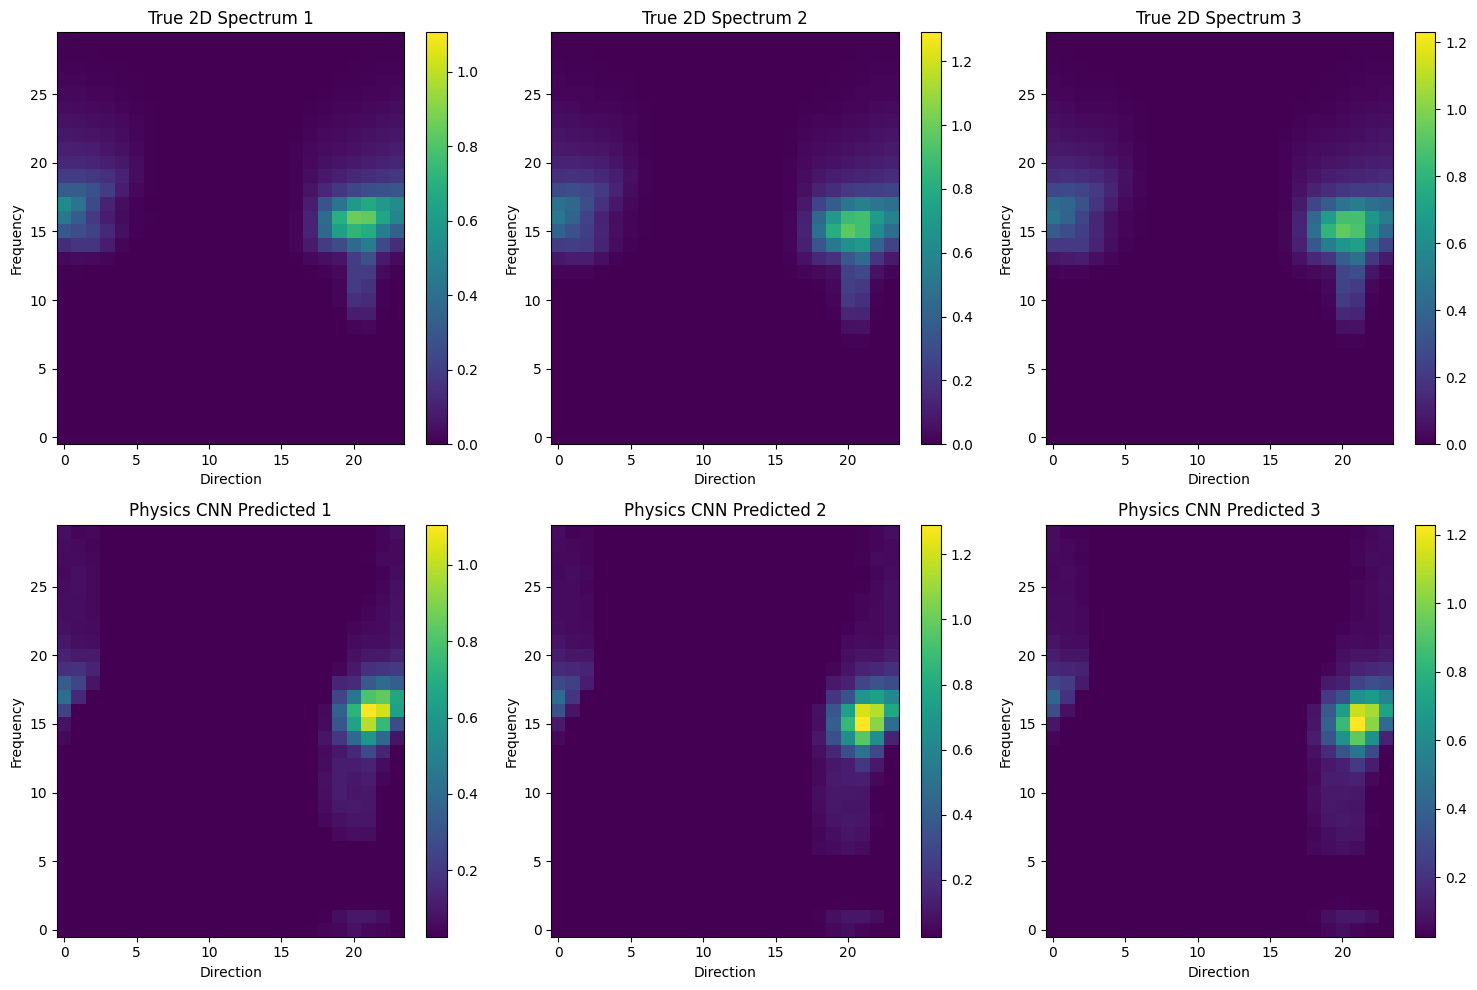

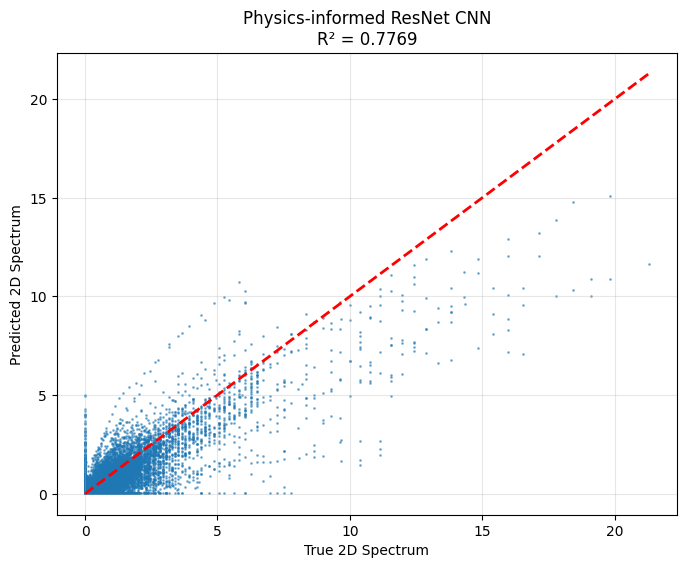

Physics-informed ResNet CNN evaluation completed!


In [11]:
# Visualize ERA5 evaluation results
import matplotlib.pyplot as plt

print("Creating visualization of Physics-informed ResNet CNN results...")

# Select 3 representative samples for visualization
sample_indices = [0, 1, 2]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot heatmaps for 3 timestamps
for i, idx in enumerate(sample_indices):
    sample_target = eval_target_np[idx]
    sample_pred = eval_pred_np[idx]
    
    # Determine common color scale for this timestamp
    vmax = max(sample_target.max(), sample_pred.max())
    
    # Top row: True spectra
    im1 = axes[0,i].imshow(sample_target, cmap='viridis', aspect='auto', origin='lower', vmax=vmax)
    axes[0,i].set_title(f'True 2D Spectrum {idx+1}')
    axes[0,i].set_xlabel('Direction')
    axes[0,i].set_ylabel('Frequency')
    plt.colorbar(im1, ax=axes[0,i])
    
    # Bottom row: Predicted spectra
    im2 = axes[1,i].imshow(sample_pred, cmap='viridis', aspect='auto', origin='lower', vmax=vmax)
    axes[1,i].set_title(f'Physics CNN Predicted {idx+1}')
    axes[1,i].set_xlabel('Direction')
    axes[1,i].set_ylabel('Frequency')
    plt.colorbar(im2, ax=axes[1,i])

plt.tight_layout()
plt.show()

# R² scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(eval_target_np.flatten(), eval_pred_np.flatten(), alpha=0.5, s=1)
plt.plot([eval_target_np.min(), eval_target_np.max()], [eval_target_np.min(), eval_target_np.max()], 'r--', lw=2)
plt.xlabel('True 2D Spectrum')
plt.ylabel('Predicted 2D Spectrum')
plt.title(f'Physics-informed ResNet CNN\nR² = {eval_r2:.4f}')
plt.grid(True, alpha=0.3)
plt.show()

print("="*70)
print("Physics-informed ResNet CNN evaluation completed!")
print("="*70)